In [ ]:
# questo è un test di git

In [2]:
%pip install matplotlib seaborn scikit-learn requests


[notice] A new release of pip available: 22.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import requests
import io
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import numpy as np
import statsmodels.api as sm
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
# from google.colab import files

In [ ]:
#download automatico dei dati istat

# 1. Definiamo l'URL e l'header richiesto
url = "https://esploradati.istat.it/SDMXWS/rest/data/41_983"
headers = {'Accept': 'application/vnd.sdmx.data+csv;version=1.0.0'}

# 2. Effettuiamo la richiesta GET
response = requests.get(url, headers=headers)

# Usiamo io.StringIO per leggere il testo della risposta come se fosse un file
path_cwd = pd.read_csv(io.StringIO(response.text))

# 3. Visualizziamo le prime righe
path_cwd.head()

In [14]:
print(response)

<Response [200]>


In [15]:
path_cwd['DATA_TYPE'].unique()

array(['KILLINJ', 'ROADACC'], dtype=object)

In [16]:
path_cwd['RESULT'].unique()

array(['F', 'M', '9'], dtype=object)

In [17]:
path_cwd['TIME_PERIOD'].unique()

array([2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011,
       2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022,
       2023, 2024])

In [18]:
path_cwd['OBS_STATUS'].unique()

array([nan])

In [19]:
# OBS_VALUE indica il dato preso in quel momento per esempio nel comune codice 1001 nel 2002 si sono registrati 10 morti / feriti (KILLINJ)

In [20]:
path_cwd['REF_AREA'].unique()
# confrontando questo risultato con il csv dei comuni vedo che la zona corrisponde ai comuni

array([  1001,   1002,   1003, ..., 111105, 111106, 111107], shape=(8578,))

In [22]:
# 1. Trasforma il DataFrame in un file CSV all'interno del tuo computer
# usa encoding='utf-8-sig' per far sì che Excel legga bene gli accenti italiani
path_cwd.to_csv('dati_istat_esportati.csv', index=False, encoding='utf-8-sig')

# 2. Su VS Code non serve scaricare nulla, il file è già sul tuo PC!
# files.download('dati_istat_esportati.csv')

In [23]:
# printo l'intero dataset per capire quante righe e colonne ci sono
print(f"Il dataset contiene {path_cwd.shape[0]} righe e {path_cwd.shape[1]} colonne.")

Il dataset contiene 573552 righe e 16 colonne.


In [24]:
# Printo il valore medio e il massimo
print(f"Valore massimo: {path_cwd['OBS_VALUE'].max()}")
print(f"Valore medio: {path_cwd['OBS_VALUE'].mean()}")

Valore massimo: 30254
Valore medio: 20.207602798002622


In [25]:
# creo una copia per non rovinare i dati originali
df_clean = path_cwd.copy()

# elimino le colonne che hanno TUTTI i valori vuoti (NaN), elimina tutte le colonne vuote con axis 1
df_clean = df_clean.dropna(axis=1, how='all')

# Cosa è rimasto
print("Colonne rimaste dopo la pulizia:")
print(df_clean.columns.tolist())

Colonne rimaste dopo la pulizia:
['DATAFLOW', 'FREQ', 'REF_AREA', 'DATA_TYPE', 'RESULT', 'TIME_PERIOD', 'OBS_VALUE']


In [26]:
# Statistiche della colonna principale
descrizione = df_clean['OBS_VALUE'].describe()
print(descrizione)

# Cerco il valore massimo
max_row = df_clean.loc[df_clean['OBS_VALUE'].idxmax()]
print(f"\nIl valore più alto registrato è {max_row['OBS_VALUE']} nell'anno {max_row['TIME_PERIOD']} (Area: {max_row['REF_AREA']})")

count    573552.000000
mean         20.207603
std         245.813966
min           0.000000
25%           0.000000
50%           1.000000
75%           8.000000
max       30254.000000
Name: OBS_VALUE, dtype: float64

Il valore più alto registrato è 30254 nell'anno 2004 (Area: 58091)


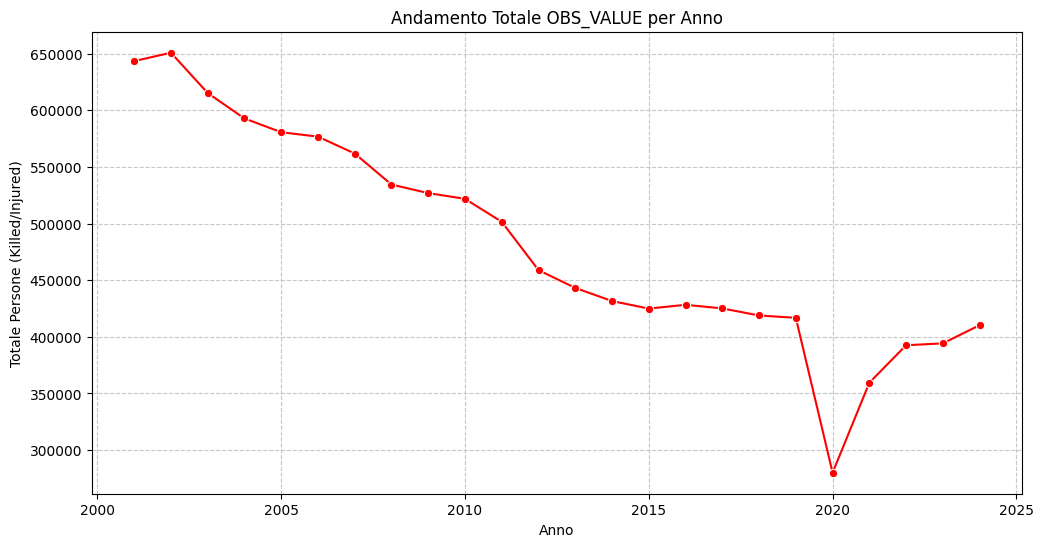

In [27]:


# Raggruppo i valori OBS_VALUE per anno e sommo i valori
trend_annuale = df_clean.groupby('TIME_PERIOD')['OBS_VALUE'].sum().reset_index()

# creo il grafico
plt.figure(figsize=(12, 6))
sns.lineplot(data=trend_annuale, x='TIME_PERIOD', y='OBS_VALUE', marker='o', color='red')
plt.title('Andamento Totale OBS_VALUE per Anno')
plt.xlabel('Anno')
plt.ylabel('Totale Persone (Killed/Injured)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#trend: sembra discendente
#valori massimi e minimi 650000, minmimo 300000
# outlier --> 2020

In [28]:
# Inseriamo il percorso del tuo computer con la 'r' davanti alle virgolette
df_comuni = pd.read_csv(r'C:\Users\gabri\Desktop\boolean\Comuni - Dimensione Data Indagine 31-12-2020 Stampa 08052026194159.csv', sep=';')

# Vedo come è strutturato il file dei comuni
df_comuni.head()

,Codice Ripartizione geografica,Codice Regione,Codice Provincia (Storico),Codice Provincia/Uts,Codice Comune (alfanumerico),Codice Comune (numerico),Comune,Comune (dizione straniera),Sigla automobilistica,Popolazione legale,Anno Censimento,Superficie (Kmq),Anno (Superficie),Popolazione residente,Anno (Popolazione residente)
0,1,1,1,201,1001,1001,Agliè,NaN,TO,2644,2011,"13,1462",2020,2545,2020
1,1,1,1,201,1002,1002,Airasca,NaN,TO,3819,2011,"15,7393",2020,3633,2020
2,1,1,1,201,1003,1003,Ala di Stura,NaN,TO,462,2011,"46,3315",2020,459,2020
3,1,1,1,201,1004,1004,Albiano d'Ivrea,NaN,TO,1791,2011,"11,7314",2020,1638,2020
4,1,1,1,201,1006,1006,Almese,NaN,TO,6303,2011,"17,8756",2020,6355,2020


In [29]:
df_join = pd.merge(df_clean, df_comuni, left_on='REF_AREA', right_on='Codice Comune (numerico)', how='left')
df_join.head()
# faccio il merge del file dei comuni con il file delle statistiche dell'istat


,DATAFLOW,FREQ,REF_AREA,DATA_TYPE,RESULT,TIME_PERIOD,OBS_VALUE,Codice Ripartizione geografica,Codice Regione,Codice Provincia (Storico),...,Codice Comune (numerico),Comune,Comune (dizione straniera),Sigla automobilistica,Popolazione legale,Anno Censimento,Superficie (Kmq),Anno (Superficie),Popolazione residente,Anno (Popolazione residente)
0,IT1:41_983(1.0),A,1001,KILLINJ,F,2001,10,1.0,1.0,1.0,...,1001.0,Agliè,NaN,TO,2644.0,2011.0,"13,1462",2020.0,2545.0,2020.0
1,IT1:41_983(1.0),A,1001,KILLINJ,F,2002,10,1.0,1.0,1.0,...,1001.0,Agliè,NaN,TO,2644.0,2011.0,"13,1462",2020.0,2545.0,2020.0
2,IT1:41_983(1.0),A,1001,KILLINJ,F,2003,7,1.0,1.0,1.0,...,1001.0,Agliè,NaN,TO,2644.0,2011.0,"13,1462",2020.0,2545.0,2020.0
3,IT1:41_983(1.0),A,1001,KILLINJ,F,2004,13,1.0,1.0,1.0,...,1001.0,Agliè,NaN,TO,2644.0,2011.0,"13,1462",2020.0,2545.0,2020.0
4,IT1:41_983(1.0),A,1001,KILLINJ,F,2005,2,1.0,1.0,1.0,...,1001.0,Agliè,NaN,TO,2644.0,2011.0,"13,1462",2020.0,2545.0,2020.0


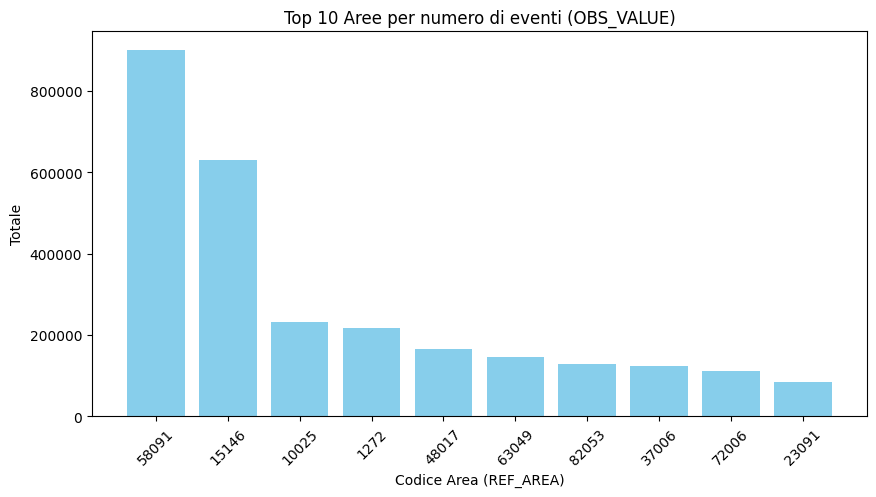

In [30]:
# Printo il grafico dei top 10 comuni con più incidenti. Questo grasfico però è fuorviante in quanto più un comune ha abitanti più incidenti avrà

top_aree = df_join.groupby('REF_AREA',as_index=False)['OBS_VALUE'].sum().sort_values(by='OBS_VALUE', ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.bar(top_aree['REF_AREA'].astype(str), top_aree['OBS_VALUE'], color='skyblue')
plt.title('Top 10 Aree per numero di eventi (OBS_VALUE)')
plt.ylabel('Totale')
plt.xlabel('Codice Area (REF_AREA)')
plt.xticks(rotation=45)
plt.show()

In [31]:
top_aree

,REF_AREA,OBS_VALUE
5114,58091,901300
1867,15146,629964
1292,10025,231413
271,1272,217874
4597,48017,165301
5499,63049,145248
7011,82053,128656
4118,37006,124514
6279,72006,111232
3242,23091,83891


In [32]:
df_join2 = pd.merge(top_aree, df_comuni, left_on='REF_AREA', right_on='Codice Comune (numerico)', how='left')
df_join2.head()

,REF_AREA,OBS_VALUE,Codice Ripartizione geografica,Codice Regione,Codice Provincia (Storico),Codice Provincia/Uts,Codice Comune (alfanumerico),Codice Comune (numerico),Comune,Comune (dizione straniera),Sigla automobilistica,Popolazione legale,Anno Censimento,Superficie (Kmq),Anno (Superficie),Popolazione residente,Anno (Popolazione residente)
0,58091,901300,3,12,58,258,58091,58091,Roma,NaN,RM,2617175,2011,"1287,3716",2020,2770226,2020
1,15146,629964,1,3,15,215,15146,15146,Milano,NaN,MI,1242123,2011,"181,6783",2020,1374582,2020
2,10025,231413,1,7,10,210,10025,10025,Genova,NaN,GE,586180,2011,"240,2876",2020,566410,2020
3,1272,217874,1,1,1,201,1272,1272,Torino,NaN,TO,872367,2011,"130,0645",2020,858205,2020
4,48017,165301,3,9,48,248,48017,48017,Firenze,NaN,FI,358079,2011,"102,3156",2020,368419,2020


In [33]:
#  Calcolo gli incidenti per 1000 abitanti
df_join2['incidenti_per_1000_ab'] = (
    df_join2['OBS_VALUE'] / df_join2['Popolazione legale'])* 1000

df_join2.head()

,REF_AREA,OBS_VALUE,Codice Ripartizione geografica,Codice Regione,Codice Provincia (Storico),Codice Provincia/Uts,Codice Comune (alfanumerico),Codice Comune (numerico),Comune,Comune (dizione straniera),Sigla automobilistica,Popolazione legale,Anno Censimento,Superficie (Kmq),Anno (Superficie),Popolazione residente,Anno (Popolazione residente),incidenti_per_1000_ab
0,58091,901300,3,12,58,258,58091,58091,Roma,NaN,RM,2617175,2011,"1287,3716",2020,2770226,2020,344.378958
1,15146,629964,1,3,15,215,15146,15146,Milano,NaN,MI,1242123,2011,"181,6783",2020,1374582,2020,507.167165
2,10025,231413,1,7,10,210,10025,10025,Genova,NaN,GE,586180,2011,"240,2876",2020,566410,2020,394.781466
3,1272,217874,1,1,1,201,1272,1272,Torino,NaN,TO,872367,2011,"130,0645",2020,858205,2020,249.750392
4,48017,165301,3,9,48,248,48017,48017,Firenze,NaN,FI,358079,2011,"102,3156",2020,368419,2020,461.632768


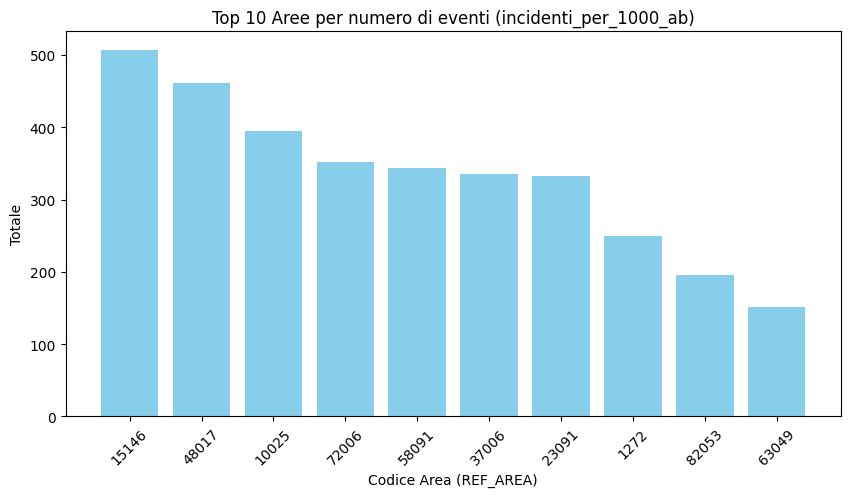

In [34]:
# printo quali comuni hanno il più alto tasso di incidenti per 1000 abitanti

top_aree2 = df_join2.groupby('REF_AREA',as_index=False)['incidenti_per_1000_ab'].sum().sort_values(by='incidenti_per_1000_ab', ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.bar(top_aree2['REF_AREA'].astype(str), top_aree2['incidenti_per_1000_ab'], color='skyblue')
plt.title('Top 10 Aree per numero di eventi (incidenti_per_1000_ab)')
plt.ylabel('Totale')
plt.xlabel('Codice Area (REF_AREA)')
plt.xticks(rotation=45)
plt.show()

Righe rimosse: 52066
Percentuale dati rimossi: 9.08%


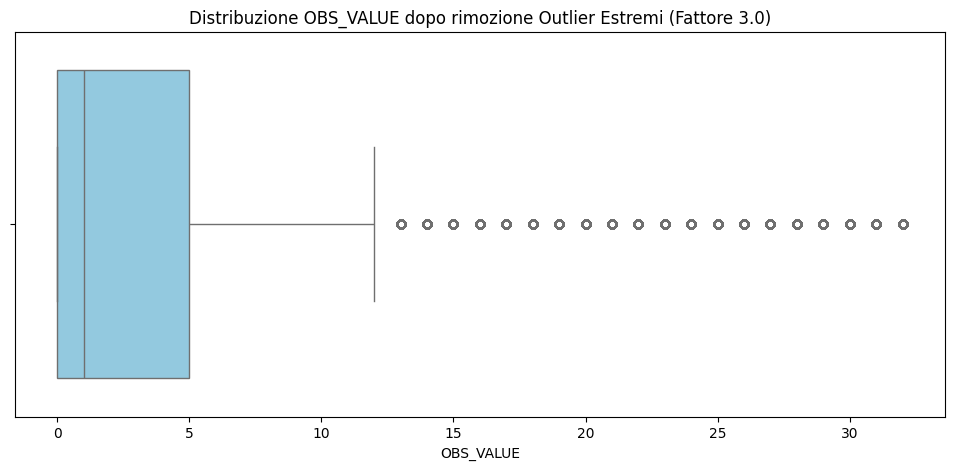

In [35]:
#tolgo gli outlier
# 1. Calcolo IQR con coefficiente 3.0 (Outlier Estremi)
# uso 3.0 invece di 1.5 per essere meno aggressivi
Q1 = df_clean['OBS_VALUE'].quantile(0.25)
Q3 = df_clean['OBS_VALUE'].quantile(0.75)
IQR = Q3 - Q1

# definisco i limiti per gli outlier estremi
limite_inferiore = Q1 - 3.0 * IQR
limite_superiore = Q3 + 3.0 * IQR

# 2. Filtro i dati
# Tengo i dati che rientrano nei limiti o che sono "fondamentali"
df_senza_outlier = df_clean[
    (df_clean['OBS_VALUE'] >= limite_inferiore) &
    (df_clean['OBS_VALUE'] <= limite_superiore)
]

# estraggo le righe che non sono outlier

# 3. verifica dei risultati
righe_rimosse = len(df_clean) - len(df_senza_outlier)
percentuale_rimossa = (righe_rimosse / len(df_clean)) * 100

print(f"Righe rimosse: {righe_rimosse}")
print(f"Percentuale dati rimossi: {percentuale_rimossa:.2f}%")

# 4. Visualizzazione di controllo

plt.figure(figsize=(12, 5))
sns.boxplot(x=df_senza_outlier['OBS_VALUE'], color='skyblue')
plt.title('Distribuzione OBS_VALUE dopo rimozione Outlier Estremi (Fattore 3.0)')
plt.show()

In [36]:
# voglio vedere il dataframe senza outlier
df_senza_outlier.head()

,DATAFLOW,FREQ,REF_AREA,DATA_TYPE,RESULT,TIME_PERIOD,OBS_VALUE
0,IT1:41_983(1.0),A,1001,KILLINJ,F,2001,10
1,IT1:41_983(1.0),A,1001,KILLINJ,F,2002,10
2,IT1:41_983(1.0),A,1001,KILLINJ,F,2003,7
3,IT1:41_983(1.0),A,1001,KILLINJ,F,2004,13
4,IT1:41_983(1.0),A,1001,KILLINJ,F,2005,2


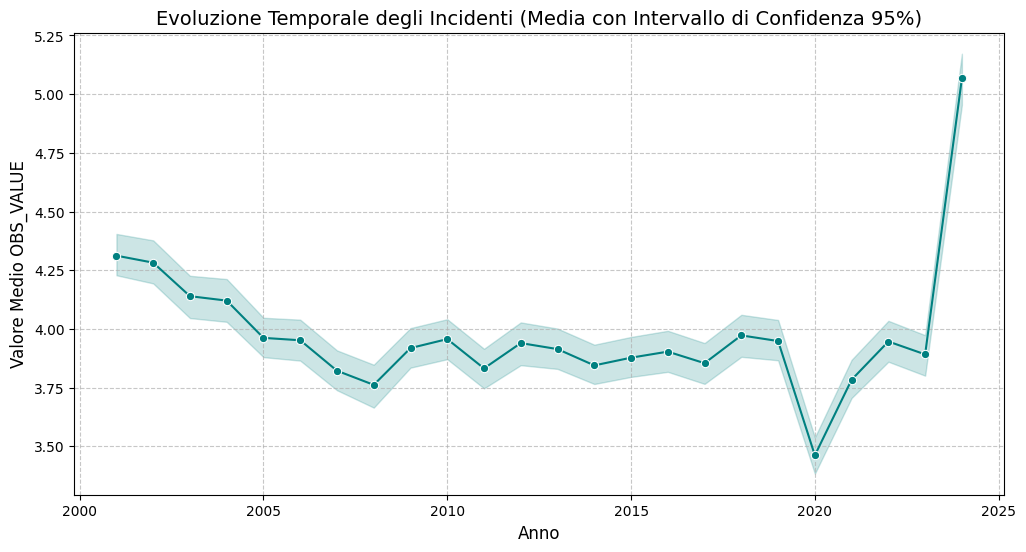

    TIME_PERIOD    sum      mean
19         2020  77192  3.461835
20         2021  83077  3.783795
21         2022  86207  3.946484
22         2023  84733  3.891655
23         2024  86375  5.066874


In [37]:
# 1. raggruppo i dati per anno (TIME_PERIOD) calcolando la media o la somma
# uso la media per vedere il "comune medio" o la somma per il totale nazionale filtrato
trend_temporale = df_senza_outlier.groupby('TIME_PERIOD')['OBS_VALUE'].agg(['mean', 'sum', 'count']).reset_index()

# 2. Creazione del grafico dcon intervallo di confidenza del 95%
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_senza_outlier, x='TIME_PERIOD', y='OBS_VALUE', color='teal', marker='o')

# Personalizzazione
plt.title('Evoluzione Temporale degli Incidenti (Media con Intervallo di Confidenza 95%)', fontsize=14)
plt.xlabel('Anno', fontsize=12)
plt.ylabel('Valore Medio OBS_VALUE', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

# Printo i dati per un controllo veloce
print(trend_temporale[['TIME_PERIOD', 'sum', 'mean']].tail())

In [38]:
print(df_senza_outlier[df_senza_outlier['TIME_PERIOD'] == 2024].describe())

            REF_AREA  TIME_PERIOD     OBS_VALUE
count   17047.000000      17047.0  17047.000000
mean    44572.072153       2024.0      5.066874
std     32227.433965          0.0      6.985343
min      1001.000000       2024.0      0.000000
25%     16243.000000       2024.0      0.000000
50%     36020.000000       2024.0      2.000000
75%     71039.500000       2024.0      7.000000
max    111107.000000       2024.0     32.000000


In [39]:
# Escludiamo il 2024 perché parziale e statisticamente non coerente
df_finale = df_senza_outlier[df_senza_outlier['TIME_PERIOD'] < 2024]

print(f"Dati pronti per la regressione. Anni inclusi: {df_finale['TIME_PERIOD'].unique()}")

Dati pronti per la regressione. Anni inclusi: [2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014
 2015 2016 2017 2018 2019 2020 2021 2022 2023]


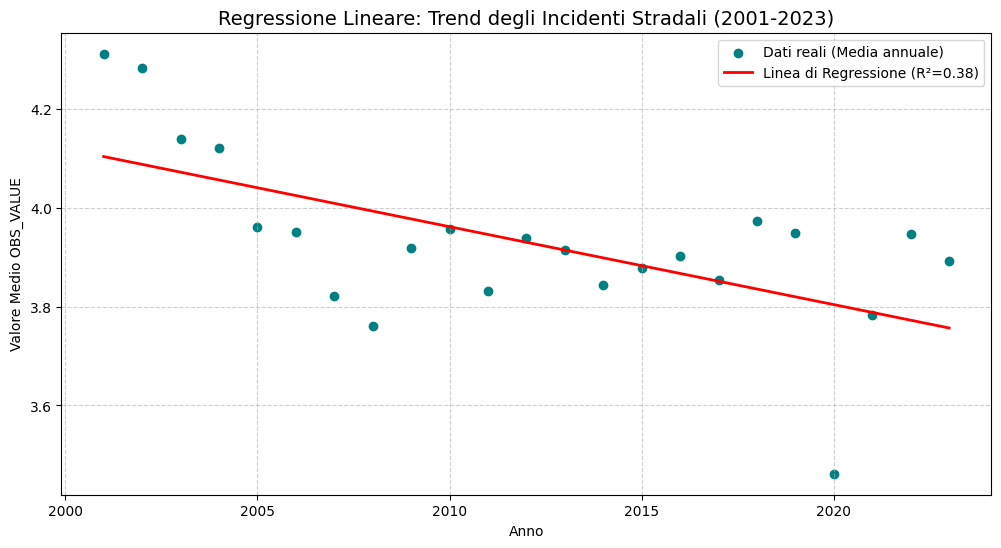

Coefficiente di determinazione (R²): 0.3795
Pendenza (Coefficiente): -0.0158
Interpretazione: Ogni anno, il valore medio cala di circa 0.0158 unità.


In [40]:
# creo una regressione lineare per verificare l'andamento degli incidenti

# 1. Preparazione dei dati: uso la media annuale per un trend pulito
trend_data = df_finale.groupby('TIME_PERIOD')['OBS_VALUE'].mean().reset_index()

X = trend_data['TIME_PERIOD'].values.reshape(-1, 1)  # Variabile indipendente (Anno)
y = trend_data['OBS_VALUE'].values                  # Variabile dipendente (Media incidenti)

# 2. Creazione e addestramento del modello
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# 3. Calcolo delle metriche di performance
r2 = model.score(X, y)
pendenza = model.coef_[0]

# 4. Visualizzazione
plt.figure(figsize=(12, 6))
plt.scatter(X, y, color='teal', label='Dati reali (Media annuale)')
plt.plot(X, y_pred, color='red', linewidth=2, label=f'Linea di Regressione (R²={r2:.2f})')

plt.title('Regressione Lineare: Trend degli Incidenti Stradali (2001-2023)', fontsize=14)
plt.xlabel('Anno')
plt.ylabel('Valore Medio OBS_VALUE')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"Coefficiente di determinazione (R²): {r2:.4f}")
print(f"Pendenza (Coefficiente): {pendenza:.4f}")
print(f"Interpretazione: Ogni anno, il valore medio cala di circa {abs(pendenza):.4f} unità.")

In [41]:
# Test di Ipotesi sulla significatività della pendenza
# obbbiettivo: capire se la diminuzione degli incidenti che vediamo nel grafico è "reale" o se potrebbe essere dovuta solo al caso
# Ipotesi Nulla La pendenza è zero (beta = 0). Il tempo non influenza il numero di incidenti.
# ipotesi Alternativa (H1): La pendenza è diversa da zero (beta < 0). Esiste un trend decrescente significativo.



# 1. Prepariamo i dati (aggiungendo una costante per l'intercetta)
X_test = sm.add_constant(X) # X sono gli anni (2001-2023)
model_stat = sm.OLS(y, X_test).fit()

# 2. Visualizziamo il riepilogo statistico
print(model_stat.summary())

# 3. Estraiamo il p-value per l'anno
p_value = model_stat.pvalues[1]

print(f"\n--- RISULTATO DEL TEST ---")
if p_value < 0.05:
    print(f"p-value = {p_value:.4f}. Rifiutiamo l'ipotesi nulla.")
    print("Esiste una relazione statisticamente significativa: gli incidenti sono diminuiti nel tempo.")
else:
    print(f"p-value = {p_value:.4f}. Non possiamo rifiutare l'ipotesi nulla.")
    print("La variazione potrebbe essere dovuta al caso.")

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.379
Model:                            OLS   Adj. R-squared:                  0.350
Method:                 Least Squares   F-statistic:                     12.84
Date:                Tue, 19 May 2026   Prob (F-statistic):            0.00175
Time:                        20:41:29   Log-Likelihood:                 13.629
No. Observations:                  23   AIC:                            -23.26
Df Residuals:                      21   BIC:                            -20.99
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         35.6649      8.855      4.028      0.0

In [42]:
# 1. Preparo i dati raggruppati per area
cluster_base = df_clean.groupby('REF_AREA')['OBS_VALUE'].agg(['mean', 'std']).fillna(0).reset_index()
cluster_base = cluster_base.dropna()
features=cluster_base[['mean', 'std']]

# 2. Creiamo la variabile X_scaled che serve per scalare i dati
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)



c:\Users\gabri\AppData\Local\Programs\Python\Python310\lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Impossibile trovare il file specificato
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\gabri\AppData\Local\Programs\Python\Python310\lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "c:\Users\gabri\AppData\Local\Programs\Python\Python310\lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
  File "c:\Users\gabri\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 501, in run
    with Popen(*popenargs, **kwargs) as process:
  File "c:\Users\gabri\

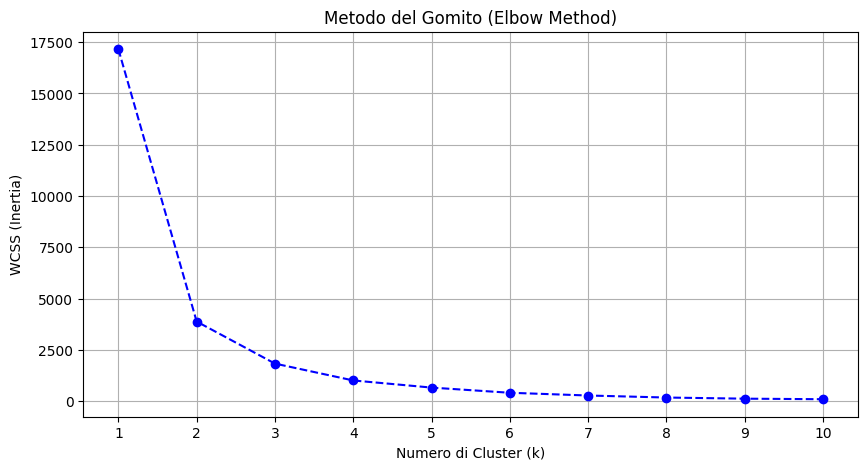

In [43]:
# 1. Caloclo la WCSS per un range di k (es. da 1 a 10)
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# 2. Metodo del Gomito
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='blue')
plt.title('Metodo del Gomito (Elbow Method)')
plt.xlabel('Numero di Cluster (k)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

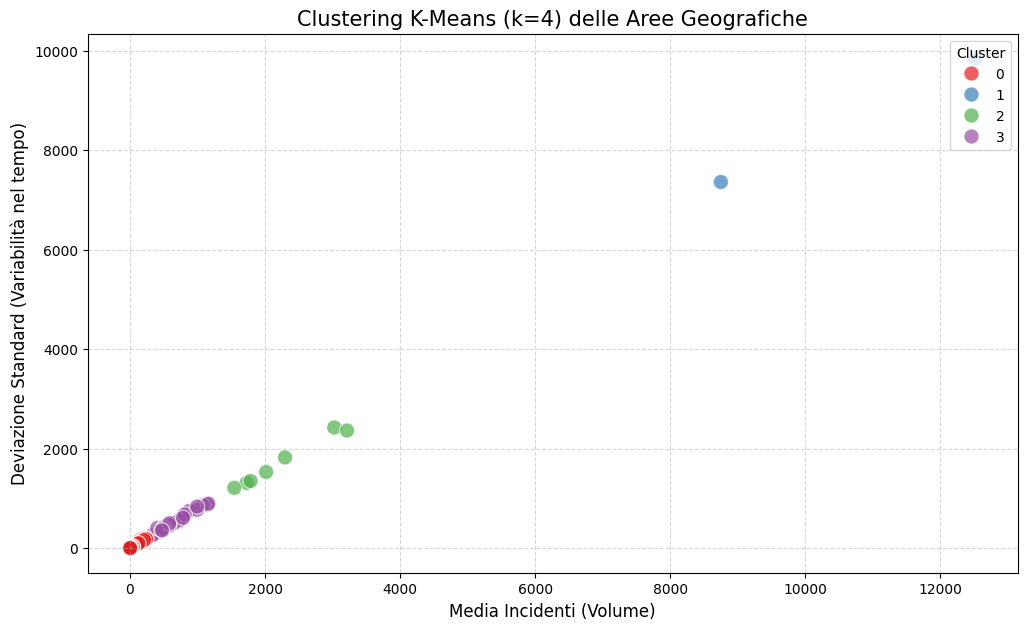

                 mean          std
cluster                           
0           11.348548     9.981687
1        10633.777778  8602.925800
2         2230.630952  1717.562384
3          508.592620   403.577902


In [44]:
# 1. Applico K-Means con k=4
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_base['cluster'] = kmeans_final.fit_predict(X_scaled)

# 2. Visualizzazione finale
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=cluster_base,
    x='mean',
    y='std',
    hue='cluster',
    palette='Set1', # Set1 rende i 4 colori molto distinti
    s=120,
    alpha=0.7,
    edgecolor='w'
)

plt.title('Clustering K-Means (k=4) delle Aree Geografiche', fontsize=15)
plt.xlabel('Media Incidenti (Volume)', fontsize=12)
plt.ylabel('Deviazione Standard (Variabilità nel tempo)', fontsize=12)
plt.legend(title='Cluster', loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Vediamo le caratteristiche medie di ogni cluster
print(cluster_base.groupby('cluster')[['mean', 'std']].mean())